# FedEx Logistics Performance Analysis - Exploratory Data Analysis 



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Name** - Kunal Jain


## ***1. Know Your Data***

Import Libraries 

In [602]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [603]:
fedex_df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')

In [604]:
fedex_df.head(10)

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN
5,23,112-NG-T01,Pre-PQ Process,SCMS-87,ASN-57,Nigeria,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,28-Sep-06,28-Sep-06,28-Sep-06,ARV,Pediatric,Aurobindo Pharma Limited,"Zidovudine 10mg/ml, oral solution, Bottle, 240 ml",Zidovudine,Generic,10mg/ml,Oral solution,240,416,2225.60,5.35,0.02,"Aurobindo Unit III, India",Yes,504,5920.42,NaN
6,44,110-ZM-T01,Pre-PQ Process,SCMS-139,ASN-130,Zambia,PMO - US,Direct Drop,DDU,Air,Pre-PQ Process,Date Not Captured,8-Jan-07,8-Jan-07,8-Jan-07,ARV,Pediatric,MERCK SHARP & DOHME IDEA GMBH (FORMALLY MERCK ...,"Efavirenz 200mg [Stocrin/Sustiva], capsule, 90...",Efavirenz,Stocrin/Sustiva,200mg,Capsule,90,135,4374.00,32.40,0.36,MSD South Granville Australia,Yes,328,Freight Included in Commodity Cost,NaN
7,45,109-TZ-T01,Pre-PQ Process,SCMS-140,ASN-94,Tanzania,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,24-Nov-06,24-Nov-06,24-Nov-06,ARV,Adult,Aurobindo Pharma Limited,"Nevirapine 200mg, tablets, 60 Tabs",Nevirapine,Generic,200mg,Tablet,60,16667,60834.55,3.65,0.06,"Aurobindo Unit III, India",Yes,1478,6212.41,NaN
8,46,112-NG-T01,Pre-PQ Process,SCMS-156,ASN-93,Nigeria,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,7-Dec-06,7-Dec-06,7-Dec-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,273,532.35,1.95,0.03,"Aurobindo Unit III, India",No,See ASN-93 (ID#:1281),See ASN-93 (ID#:1281),NaN
9,47,110-ZM-T01,Pre-PQ Process,SCMS-165,ASN-199,Zambia,PMO - US,Direct Drop,CIP,Air,Pre-PQ Process,11/13/06,30-Jan-07,30-Jan-07,30-Jan-07,ARV,Adult,ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),"Lopinavir/Ritonavir 200/50mg [Aluvia], tablets...",Lopinavir/Ritonavir,

In [605]:
# Remove the column display cap so it will show us each and every column name without limiting them
pd.set_option('display.max_columns', None)

# If your columns have long names, prevent pandas from wrapping them
pd.set_option('display.expand_frame_repr', False)

In [606]:
fedex_df.head(15)

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN
5,23,112-NG-T01,Pre-PQ Process,SCMS-87,ASN-57,Nigeria,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,28-Sep-06,28-Sep-06,28-Sep-06,ARV,Pediatric,Aurobindo Pharma Limited,"Zidovudine 10mg/ml, oral solution, Bottle, 240 ml",Zidovudine,Generic,10mg/ml,Oral solution,240,416,2225.60,5.35,0.02,"Aurobindo Unit III, India",Yes,504,5920.42,NaN
6,44,110-ZM-T01,Pre-PQ Process,SCMS-139,ASN-130,Zambia,PMO - US,Direct Drop,DDU,Air,Pre-PQ Process,Date Not Captured,8-Jan-07,8-Jan-07,8-Jan-07,ARV,Pediatric,MERCK SHARP & DOHME IDEA GMBH (FORMALLY MERCK ...,"Efavirenz 200mg [Stocrin/Sustiva], capsule, 90...",Efavirenz,Stocrin/Sustiva,200mg,Capsule,90,135,4374.00,32.40,0.36,MSD South Granville Australia,Yes,328,Freight Included in Commodity Cost,NaN
7,45,109-TZ-T01,Pre-PQ Process,SCMS-140,ASN-94,Tanzania,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,24-Nov-06,24-Nov-06,24-Nov-06,ARV,Adult,Aurobindo Pharma Limited,"Nevirapine 200mg, tablets, 60 Tabs",Nevirapine,Generic,200mg,Tablet,60,16667,60834.55,3.65,0.06,"Aurobindo Unit III, India",Yes,1478,6212.41,NaN
8,46,112-NG-T01,Pre-PQ Process,SCMS-156,ASN-93,Nigeria,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,7-Dec-06,7-Dec-06,7-Dec-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,273,532.35,1.95,0.03,"Aurobindo Unit III, India",No,See ASN-93 (ID#:1281),See ASN-93 (ID#:1281),NaN
9,47,110-ZM-T01,Pre-PQ Process,SCMS-165,ASN-199,Zambia,PMO - US,Direct Drop,CIP,Air,Pre-PQ Process,11/13/06,30-Jan-07,30-Jan-07,30-Jan-07,ARV,Adult,ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),"Lopinavir/Ritonavir 200/50mg [Aluvia], tablets...",Lopinavir/Ritonavir,

DataSet Rows and Columns Count

In [607]:
fedex_df.shape

(10324, 33)

In [608]:
fedex_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  str    
 2   PQ #                          10324 non-null  str    
 3   PO / SO #                     10324 non-null  str    
 4   ASN/DN #                      10324 non-null  str    
 5   Country                       10324 non-null  str    
 6   Managed By                    10324 non-null  str    
 7   Fulfill Via                   10324 non-null  str    
 8   Vendor INCO Term              10324 non-null  str    
 9   Shipment Mode                 9964 non-null   str    
 10  PQ First Sent to Client Date  10324 non-null  str    
 11  PO Sent to Vendor Date        10324 non-null  str    
 12  Scheduled Delivery Date       10324 non-null  str    
 13  Delivered to

Finding Duplicate Values

In [609]:
fedex_df.duplicated().sum()

np.int64(0)

Finding Missing Values or NaN Values

In [610]:
fedex_df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

Visualizing the missing values

In [611]:
missing_values = fedex_df.isnull().mean() * 100
missing_values = missing_values[missing_values > 0]

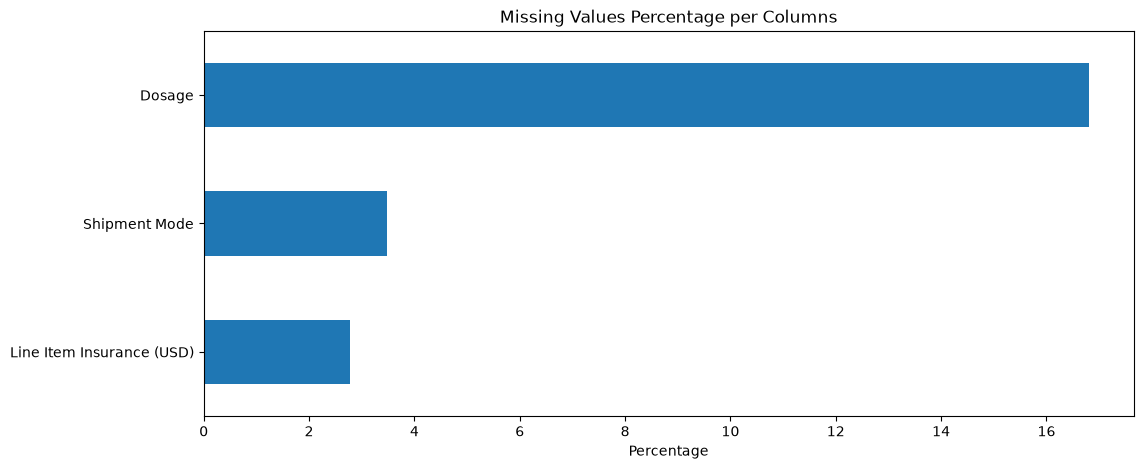

In [612]:
plt.figure(figsize=(12,5))
missing_values.sort_values().plot(kind='barh')
plt.title("Missing Values Percentage per Columns")
plt.xlabel("Percentage")
plt.show()

## ***2. Understanding Your Variables***

In [613]:
fedex_df.describe(include="all")

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324,10324,10324,10324,10324,9964,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,8588,10324,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324,10324,10324,10324,10037.000000
unique,NaN,142,1237,6233,7030,43,4,2,8,4,765,897,2006,2093,2042,5,6,73,184,86,48,54,17,NaN,NaN,NaN,NaN,NaN,88,2,4688,6733,NaN
top,NaN,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,Pre-PQ Process,N/A - From RDC,29-Aug-14,29-Aug-14,29-Aug-14,ARV,Adult,SCMS from RDC,"Efavirenz 600mg, tablets, 30 Tabs",Efavirenz,Generic,300mg,Tablet,NaN,NaN,NaN,NaN,NaN,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,NaN
freq,NaN,768,2681,67,54,1406,10265,5404,5404,6113,2476,5404,97,74,67,8550,6595,5404,755,1125,7285,990,3532,NaN,NaN,NaN,NaN,NaN,3172,7030,1507,1442,NaN
mean,51098.968229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,NaN,NaN,NaN,NaN,240.117626
std,31944.332496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,NaN,NaN,NaN,NaN,500.190568
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,12795.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,408.000000,4.314593e+03,4.120000,0.080000,NaN,NaN,NaN,NaN,6.510000
50%,57540.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,NaN,NaN,NaN,NaN,47.040000
75%,83648.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,NaN,NaN,NaN,NaN,252.400000


Variable Description 

The dataset contains a range of operational, financial, and logistics-related variables essential for analyzing FedEx’s delivery performance. Key date variables such as Scheduled Delivery Date, Delivered to Client Date, and Delivery Recorded Date help track the shipment lifecycle and compute lead times. Financial fields like Line Item Value, Freight Cost (USD), and Insurance Cost capture the economic dimensions of each shipment. Operational attributes—including Shipment Mode, Vendor, Product Group, Weight (Kilograms), and Country—provide insights into routing, vendor efficiency, and cost drivers. Additional product-level details such as Dosage, Brand, and Molecule/Test Type allow deeper segmentation of item categories. Together, these variables offer a complete foundation for evaluating service reliability, cost efficiency, and overall logistics performance.

Check Unique Value for Each Variable 

In [614]:
fedex_df.nunique()

ID                              10324
Project Code                      142
PQ #                             1237
PO / SO #                        6233
ASN/DN #                         7030
Country                            43
Managed By                          4
Fulfill Via                         2
Vendor INCO Term                    8
Shipment Mode                       4
PQ First Sent to Client Date      765
PO Sent to Vendor Date            897
Scheduled Delivery Date          2006
Delivered to Client Date         2093
Delivery Recorded Date           2042
Product Group                       5
Sub Classification                  6
Vendor                             73
Item Description                  184
Molecule/Test Type                 86
Brand                              48
Dosage                             54
Dosage Form                        17
Unit of Measure (Per Pack)         31
Line Item Quantity               5065
Line Item Value                  8741
Pack Price  

## 3. ***Data Wrangling***

In [615]:
fedex_df.columns = fedex_df.columns.str.replace(" ", "_").str.lower()

In [616]:
#Convert Date Columns
date_cols = ["PQ First Sent to Client Date", "PO Sent to Vendor Date",
             "Scheduled Delivery Date", "Delivered to Client Date"]

for col in date_cols:
    if col in fedex_df.columns:
        fedex_df[col] = pd.to_datetime(fedex_df[col], errors='coerce')


In [617]:
#Convert Numerical Line

num_cols = ["line_item_quantity", "line_item_value",
            "pack_price", "unit_price", "weight_(kilograms)", "freight_cost_(usd)"]

for col in num_cols:
    if col in fedex_df.columns:
        fedex_df[col] = pd.to_numeric(fedex_df[col], errors="coerce")

In [618]:
#There is lot of invalid value in these column (Like Date Not Captured) so i can create issue later on part of Analysis 

fedex_df[["po_sent_to_vendor_date", "delivered_to_client_date", "scheduled_delivery_date", "pq_first_sent_to_client_date"]]

,po_sent_to_vendor_date,delivered_to_client_date,scheduled_delivery_date,pq_first_sent_to_client_date
0,Date Not Captured,2-Jun-06,2-Jun-06,Pre-PQ Process
1,Date Not Captured,14-Nov-06,14-Nov-06,Pre-PQ Process
2,Date Not Captured,27-Aug-06,27-Aug-06,Pre-PQ Process
3,Date Not Captured,1-Sep-06,1-Sep-06,Pre-PQ Process
4,Date Not Captured,11-Aug-06,11-Aug-06,Pre-PQ Process
...,...,...,...,...
10319,N/A - From RDC,15-Jul-15,31-Jul-15,10/16/14
10320,N/A - From RDC,6-Aug-15,31-Jul-15,10/24/14
10321,N/A - From RDC,25-Aug-15,31-Aug-15,8/12/14
10322,N/A - From RDC,4-Aug-15,9-Sep-15,7/1/15


In [619]:
# Replace invalid values (Like Date Not Captured) with NaN
fedex_df["po_sent_to_vendor_date"] = fedex_df["po_sent_to_vendor_date"].replace(
    "Date Not Captured", np.nan
)

fedex_df["delivered_to_client_date"] = fedex_df["delivered_to_client_date"].replace(
    "Date Not Captured", np.nan
)

fedex_df["scheduled_delivery_date"] = fedex_df["scheduled_delivery_date"].replace(
    "Date Not Captured", np.nan
)

fedex_df["pq_first_sent_to_client_date"] = fedex_df["pq_first_sent_to_client_date"].replace(
    "Date Not Captured", np.nan
)

In [622]:
fedex_df[["po_sent_to_vendor_date", "delivered_to_client_date", "scheduled_delivery_date", "pq_first_sent_to_client_date"]]

,po_sent_to_vendor_date,delivered_to_client_date,scheduled_delivery_date,pq_first_sent_to_client_date
0,NaT,2006-06-02,2006-06-02,NaT
1,NaT,2006-11-14,2006-11-14,NaT
2,NaT,2006-08-27,2006-08-27,NaT
3,NaT,2006-09-01,2006-09-01,NaT
4,NaT,2006-08-11,2006-08-11,NaT
...,...,...,...,...
10319,NaT,2015-07-15,2015-07-31,2014-10-16
10320,NaT,2015-08-06,2015-07-31,2014-10-24
10321,NaT,2015-08-25,2015-08-31,2014-08-12
10322,NaT,2015-08-04,2015-09-09,2015-07-01


In [621]:
fedex_df["po_sent_to_vendor_date"] = pd.to_datetime(
    fedex_df["po_sent_to_vendor_date"],
    format="mixed",
    errors="coerce"
)

fedex_df["delivered_to_client_date"] = pd.to_datetime(
    fedex_df["delivered_to_client_date"],
    format="mixed",
    errors="coerce"
)

fedex_df["scheduled_delivery_date"] = pd.to_datetime(
    fedex_df["scheduled_delivery_date"],
    format="mixed",
    errors="coerce"
)

fedex_df["pq_first_sent_to_client_date"] = pd.to_datetime(
    fedex_df["pq_first_sent_to_client_date"],
    format="mixed",
    errors="coerce"
)

In [623]:
fedex_df[
    [
        "po_sent_to_vendor_date",
        "delivered_to_client_date"
    ]
].dtypes

po_sent_to_vendor_date      datetime64[us]
delivered_to_client_date    datetime64[us]
dtype: object

In [624]:
#Lead Time(in Days)
fedex_df["lead_time"] = (
    fedex_df["delivered_to_client_date"] -
    fedex_df["po_sent_to_vendor_date"]
).dt.days

In [625]:
#On-Time Delivery Flag
fedex_df["on_time"] = np.where(
    fedex_df["delivered_to_client_date"] <= fedex_df["scheduled_delivery_date"], 1, 0
)

In [626]:
#Basic KPIs
print("Total Shipments:", len(fedex_df))
print("Average Lead Time:", fedex_df["lead_time"].mean())
print("On-Time Delivery Rate:", fedex_df["on_time"].mean())


Total Shipments: 10324
Average Lead Time: 105.55858013937282
On-Time Delivery Rate: 0.8851220457187137


In [627]:
#Converting 'Weight_(kilogram)' and 'freight_cost_(usd)' datatype from 'Object' to 'float'
# Clean Weight (Kilograms)
fedex_df['weight_(kilograms)'] = (
    fedex_df['weight_(kilograms)']
    .astype(str)
    .str.replace(",", "")                # remove commas
    .str.replace("$", "")                # remove currency symbols (just in case)
    .str.extract(r'(\d*\.?\d+)')          # extract numeric part only
)

fedex_df['weight_(kilograms)'] = pd.to_numeric(fedex_df['weight_(kilograms)'], errors='coerce')

# Clean Freight Cost (USD)
fedex_df['freight_cost_(usd)'] = (
    fedex_df['freight_cost_(usd)']
    .astype(str)
    .str.replace(",", "")
    .str.replace("$", "")
    .str.extract(r'(\d*\.?\d+)')          # extract only digits + decimals
)

fedex_df['freight_cost_(usd)'] = pd.to_numeric(fedex_df['freight_cost_(usd)'], errors='coerce')


#Verify Conversion
fedex_df[['weight_(kilograms)', 'freight_cost_(usd)']].info()
fedex_df[['weight_(kilograms)', 'freight_cost_(usd)']].head()

#Handling Missing or Invalid Values
fedex_df['weight_(kilograms)'] = fedex_df['weight_(kilograms)'].fillna(fedex_df['weight_(kilograms)'].median())
fedex_df['freight_cost_(usd)'] = fedex_df['freight_cost_(usd)'].fillna(fedex_df['freight_cost_(usd)'].median())



<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   weight_(kilograms)  6372 non-null   float64
 1   freight_cost_(usd)  6198 non-null   float64
dtypes: float64(2)
memory usage: 161.4 KB


In [628]:
#Freight Cost Per KG
fedex_df["freight_per_kg"] = fedex_df["freight_cost_(usd)"] / fedex_df["weight_(kilograms)"]


In [629]:
#Basic KPIs
print("Total Freight Cost:", fedex_df["freight_cost_(usd)"].sum())
print("Average Freight per KG:", fedex_df["freight_per_kg"].mean())

Total Freight Cost: 93036045.94
Average Freight per KG: inf


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Lead Time Distribution


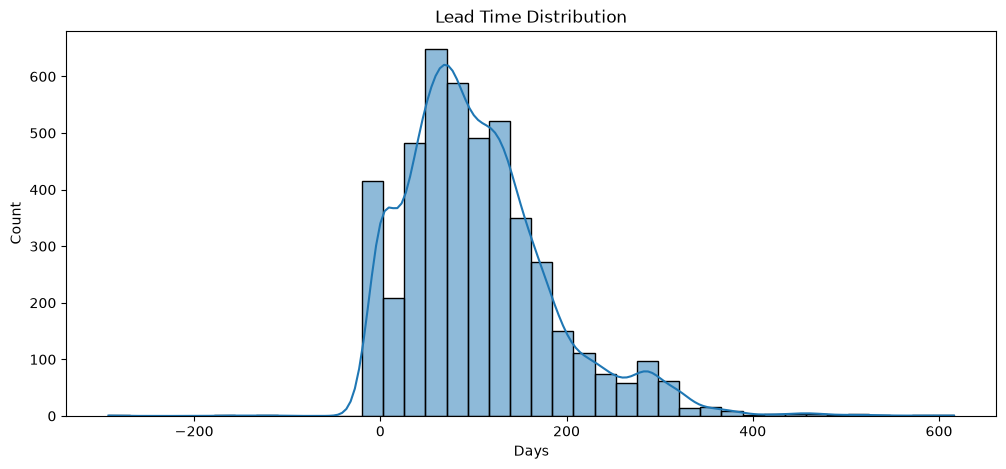

In [630]:
plt.figure(figsize=(12,5))
sns.histplot(fedex_df["lead_time"].dropna(), bins=40, kde=True)
plt.title("Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()


#### Chart - 2 Freight Cost Distribution

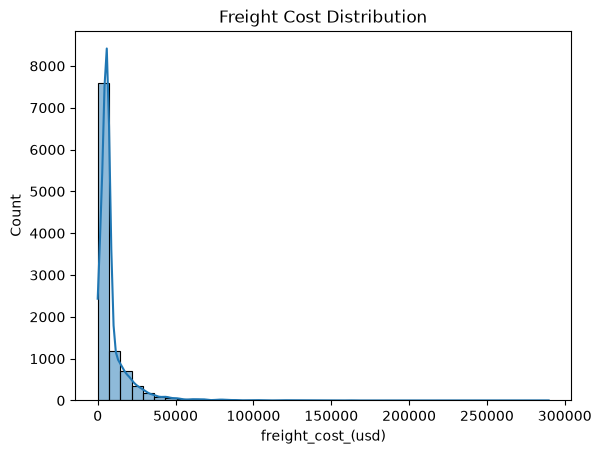

In [631]:
sns.histplot(fedex_df["freight_cost_(usd)"].dropna(), bins=40, kde=True)
plt.title("Freight Cost Distribution")
plt.show()


#### Chart - 3 Freight Cost by Country (Top 10)

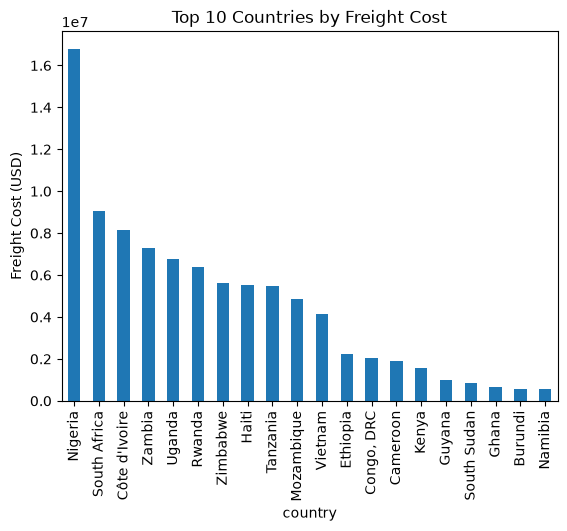

In [635]:
if "country" in fedex_df.columns:
    top10 = fedex_df.groupby("country")["freight_cost_(usd)"].sum().sort_values(ascending=False).head(20)

    top10.plot(kind="bar")
    plt.title("Top 10 Countries by Freight Cost")
    plt.ylabel("Freight Cost (USD)")
    plt.show()


#### Chart - 4 Lead Time By Shippment Mode

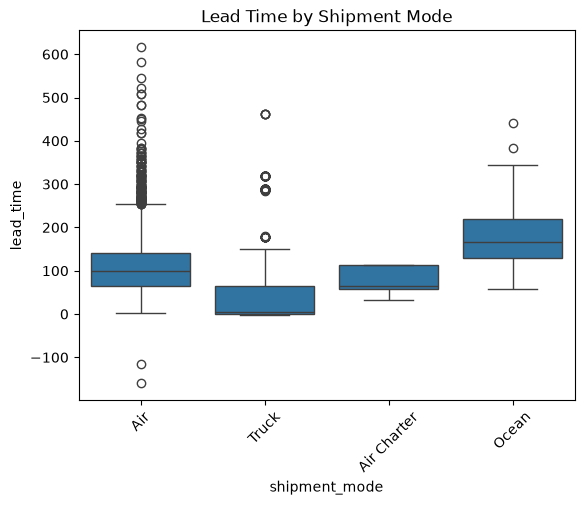

In [636]:
if "shipment_mode" in fedex_df.columns:
    sns.boxplot(x="shipment_mode", y="lead_time", data=fedex_df)
    plt.title("Lead Time by Shipment Mode")
    plt.xticks(rotation=45)
    plt.show()


#### Chart - 5 Monthly On-Time Delivery Trend

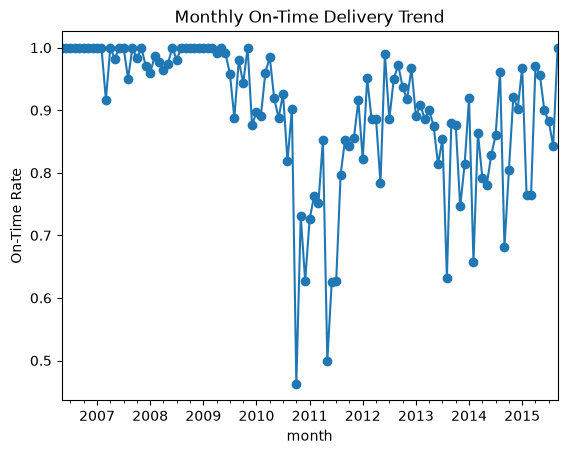

In [637]:
fedex_df["month"] = fedex_df["delivered_to_client_date"].dt.to_period("M")

monthly_ontime = fedex_df.groupby("month")["on_time"].mean()

monthly_ontime.plot(kind="line", marker="o")
plt.title("Monthly On-Time Delivery Trend")
plt.ylabel("On-Time Rate")
plt.show()


#### Chart - 6 Correlation Heatmap

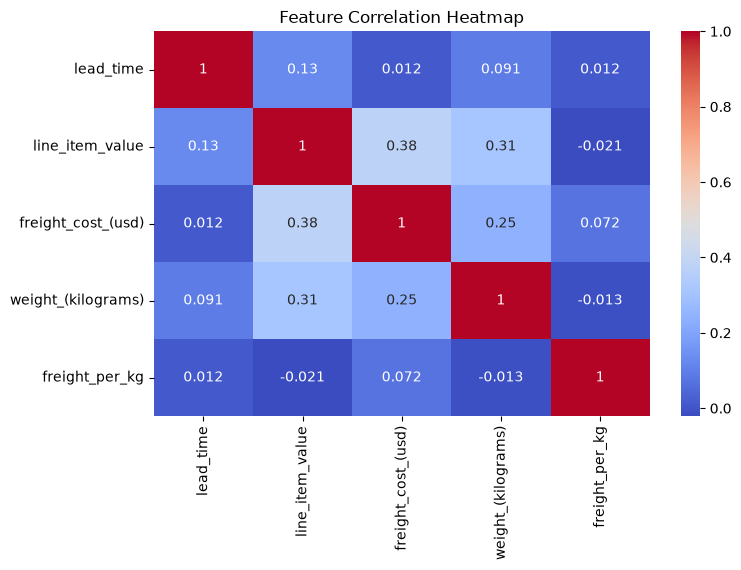

In [638]:
num_df = fedex_df[["lead_time","line_item_value","freight_cost_(usd)","weight_(kilograms)","freight_per_kg"]]

plt.figure(figsize=(8,5))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

To achieve the business objective of improving logistics performance, the client should focus on optimizing shipment routes, prioritizing faster and more reliable transportation modes, and strengthening relationships with high-performing vendors. Continuous monitoring of key KPIs—such as lead time, on-time delivery rate, freight cost per kilogram, and shipment mode efficiency—will help identify operational gaps early. The client should also analyze freight cost drivers to reduce unnecessary spending and improve cost efficiency across regions. Implementing data-driven decision-making, improving shipment scheduling accuracy, and streamlining vendor coordination can further enhance end-to-end delivery performance. Overall, using insights from this analysis will enable FedEx to deliver shipments faster, more reliably, and at optimized costs.

# **Conclusion**

This analysis provides a comprehensive view of FedEx’s logistics performance by examining key metrics such as lead time, freight cost, shipment mode efficiency, and on-time delivery trends. The findings highlight areas of operational strength as well as opportunities for improvement, particularly in optimizing transportation modes and reducing cost variability across regions. By understanding the factors that influence delivery delays and logistics expenses, FedEx can take targeted actions to enhance service reliability. The insights also show that improved shipment planning, vendor coordination, and cost monitoring can directly contribute to better performance outcomes. Overall, the project equips FedEx with actionable, data-driven recommendations to streamline its logistics network, reduce inefficiencies, and deliver a superior customer experience.